In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [1]:
#launching  dataset
import kagglehub

# Download latest version
path = kagglehub.dataset_download("imdevskp/corona-virus-report")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'corona-virus-report' dataset.
Path to dataset files: /kaggle/input/corona-virus-report


Data Loading And Preprocessing

In [9]:
#Loading the dataset using pandas

file_path = "/kaggle/input/corona-virus-report/covid_19_clean_complete.csv"
file = pd.read_csv(file_path)

In [10]:
#understanding the dataset

file.describe()

,Lat,Long,Confirmed,Deaths,Recovered,Active
count,49068.000000,49068.000000,4.906800e+04,49068.000000,4.906800e+04,4.906800e+04
mean,21.433730,23.528236,1.688490e+04,884.179160,7.915713e+03,8.085012e+03
std,24.950320,70.442740,1.273002e+05,6313.584411,5.480092e+04,7.625890e+04
min,-51.796300,-135.000000,0.000000e+00,0.000000,0.000000e+00,-1.400000e+01
25%,7.873054,-15.310100,4.000000e+00,0.000000,0.000000e+00,0.000000e+00
50%,23.634500,21.745300,1.680000e+02,2.000000,2.900000e+01,2.600000e+01
75%,41.204380,80.771797,1.518250e+03,30.000000,6.660000e+02,6.060000e+02
max,71.706900,178.065000,4.290259e+06,148011.000000,1.846641e+06,2.816444e+06


In [11]:
file.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Province/State  14664 non-null  object 
 1   Country/Region  49068 non-null  object 
 2   Lat             49068 non-null  float64
 3   Long            49068 non-null  float64
 4   Date            49068 non-null  object 
 5   Confirmed       49068 non-null  int64  
 6   Deaths          49068 non-null  int64  
 7   Recovered       49068 non-null  int64  
 8   Active          49068 non-null  int64  
 9   WHO Region      49068 non-null  object 
dtypes: float64(2), int64(4), object(4)
memory usage: 3.7+ MB


In [12]:
file['Date'] = pd.to_datetime(file['Date'])

In [13]:
file.head()

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


Global Trend Analysis

In [14]:
confirm_case = file.groupby('Date')['Confirmed'].sum()
confirm_case

,Confirmed
Date,
2020-01-22,555
2020-01-23,654
2020-01-24,941
2020-01-25,1434
2020-01-26,2118
...,...
2020-07-23,15510481
2020-07-24,15791645
2020-07-25,16047190


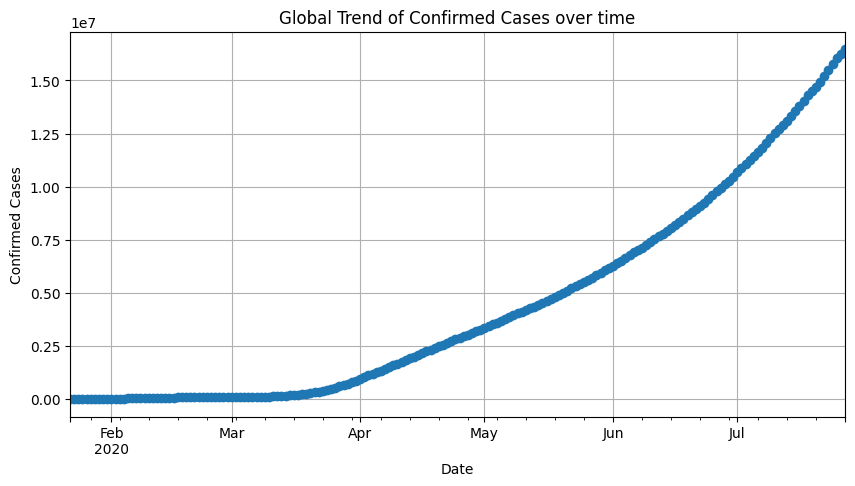

In [15]:
confirm_case.plot(kind='line', marker='o', figsize=(10, 5))

plt.title("Global Trend of Confirmed Cases over time")
plt.xlabel("Date")
plt.ylabel("Confirmed Cases")
plt.grid("True")
plt.show()

Top Countries Analysis

In [21]:
latest_date =  file['Date'].max()
latest_data = file[file['Date']== latest_date]
latest_data

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
48807,NaN,Afghanistan,33.939110,67.709953,2020-07-27,36263,1269,25198,9796,Eastern Mediterranean
48808,NaN,Albania,41.153300,20.168300,2020-07-27,4880,144,2745,1991,Europe
48809,NaN,Algeria,28.033900,1.659600,2020-07-27,27973,1163,18837,7973,Africa
48810,NaN,Andorra,42.506300,1.521800,2020-07-27,907,52,803,52,Europe
48811,NaN,Angola,-11.202700,17.873900,2020-07-27,950,41,242,667,Africa
...,...,...,...,...,...,...,...,...,...,...
49063,NaN,Sao Tome and Principe,0.186400,6.613100,2020-07-27,865,14,734,117,Africa
49064,NaN,Yemen,15.552727,48.516388,2020-07-27,1691,483,833,375,Eastern Mediterranean
49065,NaN,Comoros,-11.645500,43.333300,2020-07-27,354,7,328,19,Africa
49066,NaN,Tajikistan,38.861000,71.276100,2020-07-27,7235,60,6028,1147,Europe


In [27]:
country_wise = latest_data.groupby('Country/Region')['Confirmed'].sum().sort_values(ascending=False).head(10)
country_wise

,Confirmed
Country/Region,
US,4290259
Brazil,2442375
India,1480073
Russia,816680
South Africa,452529
Mexico,395489
Peru,389717
Chile,347923
United Kingdom,301708


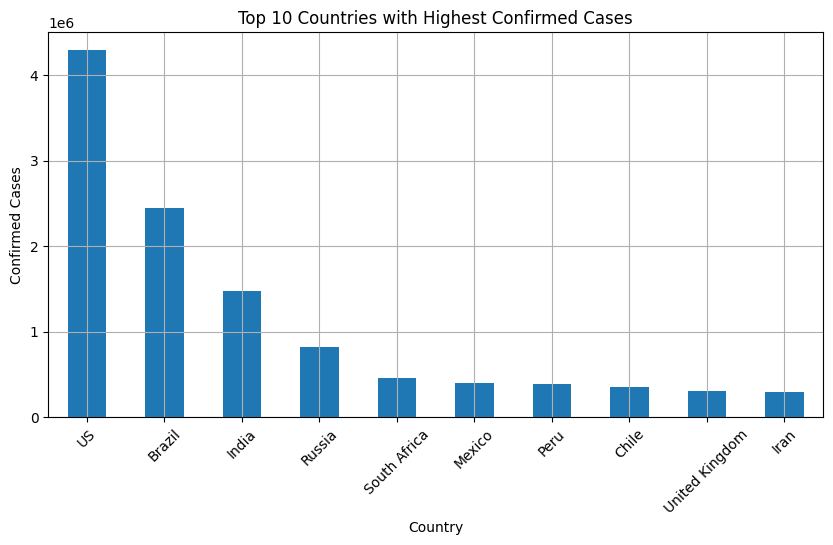

In [28]:
country_wise.plot(kind='bar', figsize=(10, 5))

plt.title("Top 10 Countries with Highest Confirmed Cases")
plt.xlabel("Country")
plt.xticks(rotation = 45)
plt.ylabel("Confirmed Cases")
plt.grid("True")
plt.show()

HeatMap Visualisation

In [35]:
df_top10 = file[file['Country/Region'].isin(country_wise.index)]
pivot_table = df_top10.pivot_table(index = 'Country/Region', columns = 'Date', values = 'Confirmed', aggfunc = 'sum')
pivot_table = pivot_table.reindex(country_wise.index)

<Figure size 640x480 with 0 Axes>

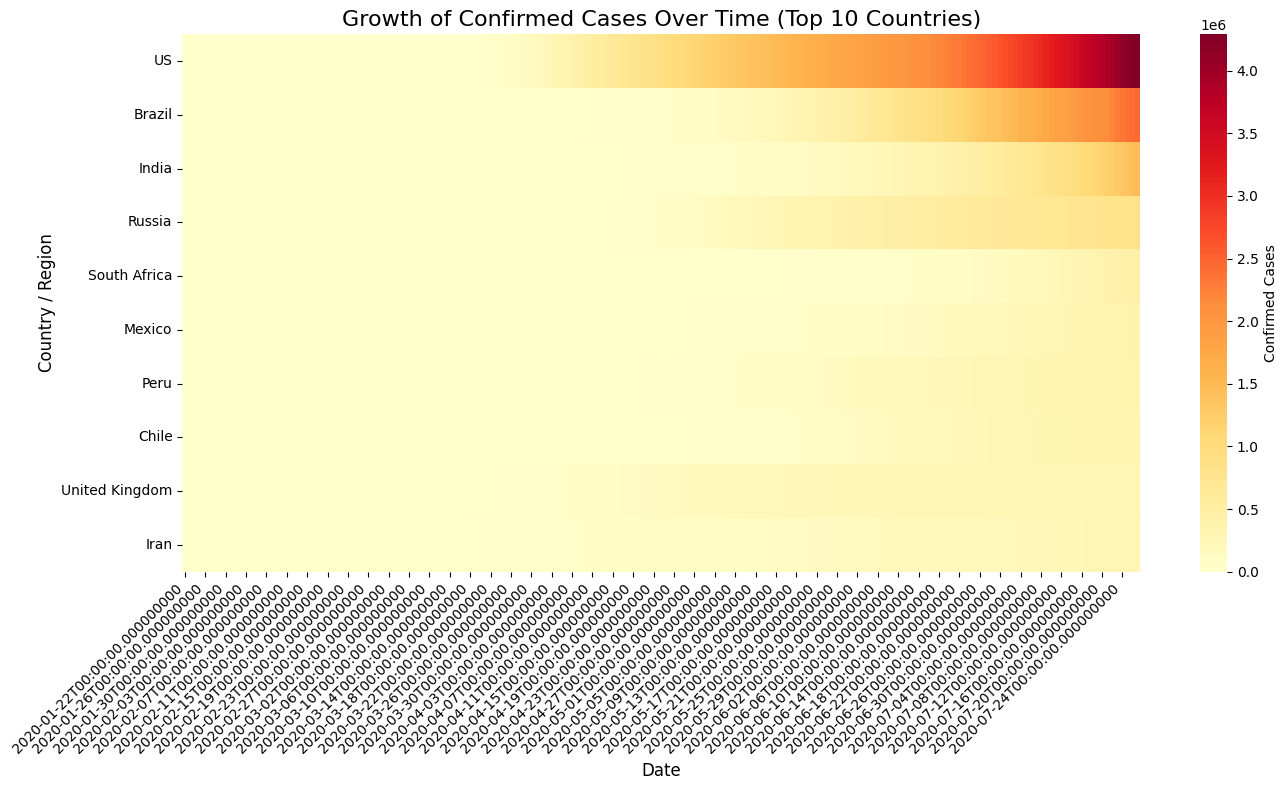

<Figure size 640x480 with 0 Axes>

In [36]:
plt.figure(figsize=(14, 8))
sns.heatmap(
    pivot_table,
    cmap="YlOrRd",
    cbar_kws={"label": "Confirmed Cases"},
)

plt.title("Growth of Confirmed Cases Over Time (Top 10 Countries)", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Country / Region", fontsize=12)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.figure()